System Reccomendation Music By Mood and Genre Using Transformer
---
---
Dataset By Spotify Preview Music

Spotify Global Music Dataset (2009–2025)

https://www.kaggle.com/datasets/wardabilal/spotify-global-music-dataset-20092025

---

Library

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
import pickle
import warnings
from IPython.display import display, HTML
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import set_config
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

Data Collecting

In [21]:
print("Load Dataset...")
df = pd.read_csv("merged_spotify_data.csv")

print(f"Data successfully loaded: {df.shape[0]} rows and {df.shape[1]} columns")
display(df.head(10))

Load Dataset...
Data successfully loaded: 427 rows and 17 columns


,track_id,track_name,artist_name,artist_genres,album_name,track_popularity,explicit,track_duration_min,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,19KlZwqlT3fguP2BeHF1Q1,Disease,Lady Gaga,"art pop, pop",Disease,70,False,3.83,0.562,0.917,-2.768,0.1170,0.05130,0.000000,0.4880,0.501,100.987
1,3bg2qahpZmsg5wV2EMPXIk,Forever Young,David Guetta,edm,Forever Young,73,False,2.61,0.558,0.655,-5.476,0.0379,0.20800,0.000000,0.0854,0.390,129.890
2,5vNRhkKd0yEAg8suGBpjeY,APT.,ROSÉ,k-pop,APT.,88,False,2.83,0.777,0.783,-4.477,0.2600,0.02830,0.000000,0.3550,0.939,149.027
3,5vNRhkKd0yEAg8suGBpjeY,APT.,ROSÉ,k-pop,APT.,88,False,2.83,0.777,0.783,-4.477,0.2600,0.02830,0.000000,0.3550,0.939,149.027
4,1Cbl3Yq8rHo7hhDQmLQagU,PUSH 2 START,Tyla,afrobeats,TYLA +,80,False,2.61,0.683,0.814,-3.505,0.0466,0.27700,0.008260,0.0858,0.758,93.482
5,1Cbl3Yq8rHo7hhDQmLQagU,PUSH 2 START,Tyla,afrobeats,TYLA +,80,False,2.61,0.683,0.814,-3.505,0.0466,0.27700,0.008260,0.0858,0.758,93.482
6,2CspwnypzT7rcWI9RfsoSb,Mantra,JENNIE,k-pop,Mantra,73,True,2.27,0.894,0.725,-4.984,0.0432,0.00434,0.000012,0.0815,0.838,116.988
7,1Es7AUAhQvapIcoh3qMKDL,Timeless (feat. Playboi Carti),The Weeknd,"r&b pop, alternative r&b, hip hop, synthpop",Timeless,19,True,4.26,0.769,0.722,-5.485,0.0507,0.05840,0.000003,0.1110,0.570,119.973
8,1Es7AUAhQvapIcoh3qMKDL,Timeless (feat. Playboi Carti),The Weeknd,"r&b pop, alternative r&b, hip hop, synthpop",Timeless,19,True,4.26,0.769,0.722,-5.485,0.0507,0.05840,0.000003,0.1110,0.570,119.973
9,1Es7AUAhQvapIcoh3qMKDL,Timeless (feat. Playboi Carti),The Weeknd,"r&b pop, alternative r&b, hip hop, synthpop",Timeless,19,True,4.26,0.769,0.722,-5.485,0.0507,0.05840,0.000003,0.1110,0.570,119.973


Preprocessing

In [22]:
print("Cleaning and process the data...")
df.replace("N/A", np.nan, inplace=True)
df.dropna(subset=["artist_genres", "track_name", "artist_name"], inplace=True)

# Put genre into mood categorize
def assign_mood_nlp(genre_text):
    genre = str(genre_text).lower()
    if any(k in genre for k in ["rock", "metal", "punk", "dance", "electronic", "house", "hip hop"]):
        return "Energetic"
    elif any(k in genre for k in ["pop", "disco", "country", "reggae"]):
        return "Happy"
    elif any(k in genre for k in ["jazz", "lo-fi", "acoustic", "r&b", "chill", "blues", "classical"]):
        return "Chill"
    else:
        return "Sad"

# DataFrame Target Mood
df["mood"] = df["artist_genres"].apply(assign_mood_nlp)

# Select Audio Features for ML
audio_features = ["danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo"]
df.dropna(subset=audio_features + ["artist_genres"], inplace=True)
df["text_feature"] = df["artist_genres"]

print(f"Preprocessing complete. Total clean data: {df.shape[0]} rows.")

Cleaning and process the data...
Preprocessing complete. Total clean data: 427 rows.


EDA

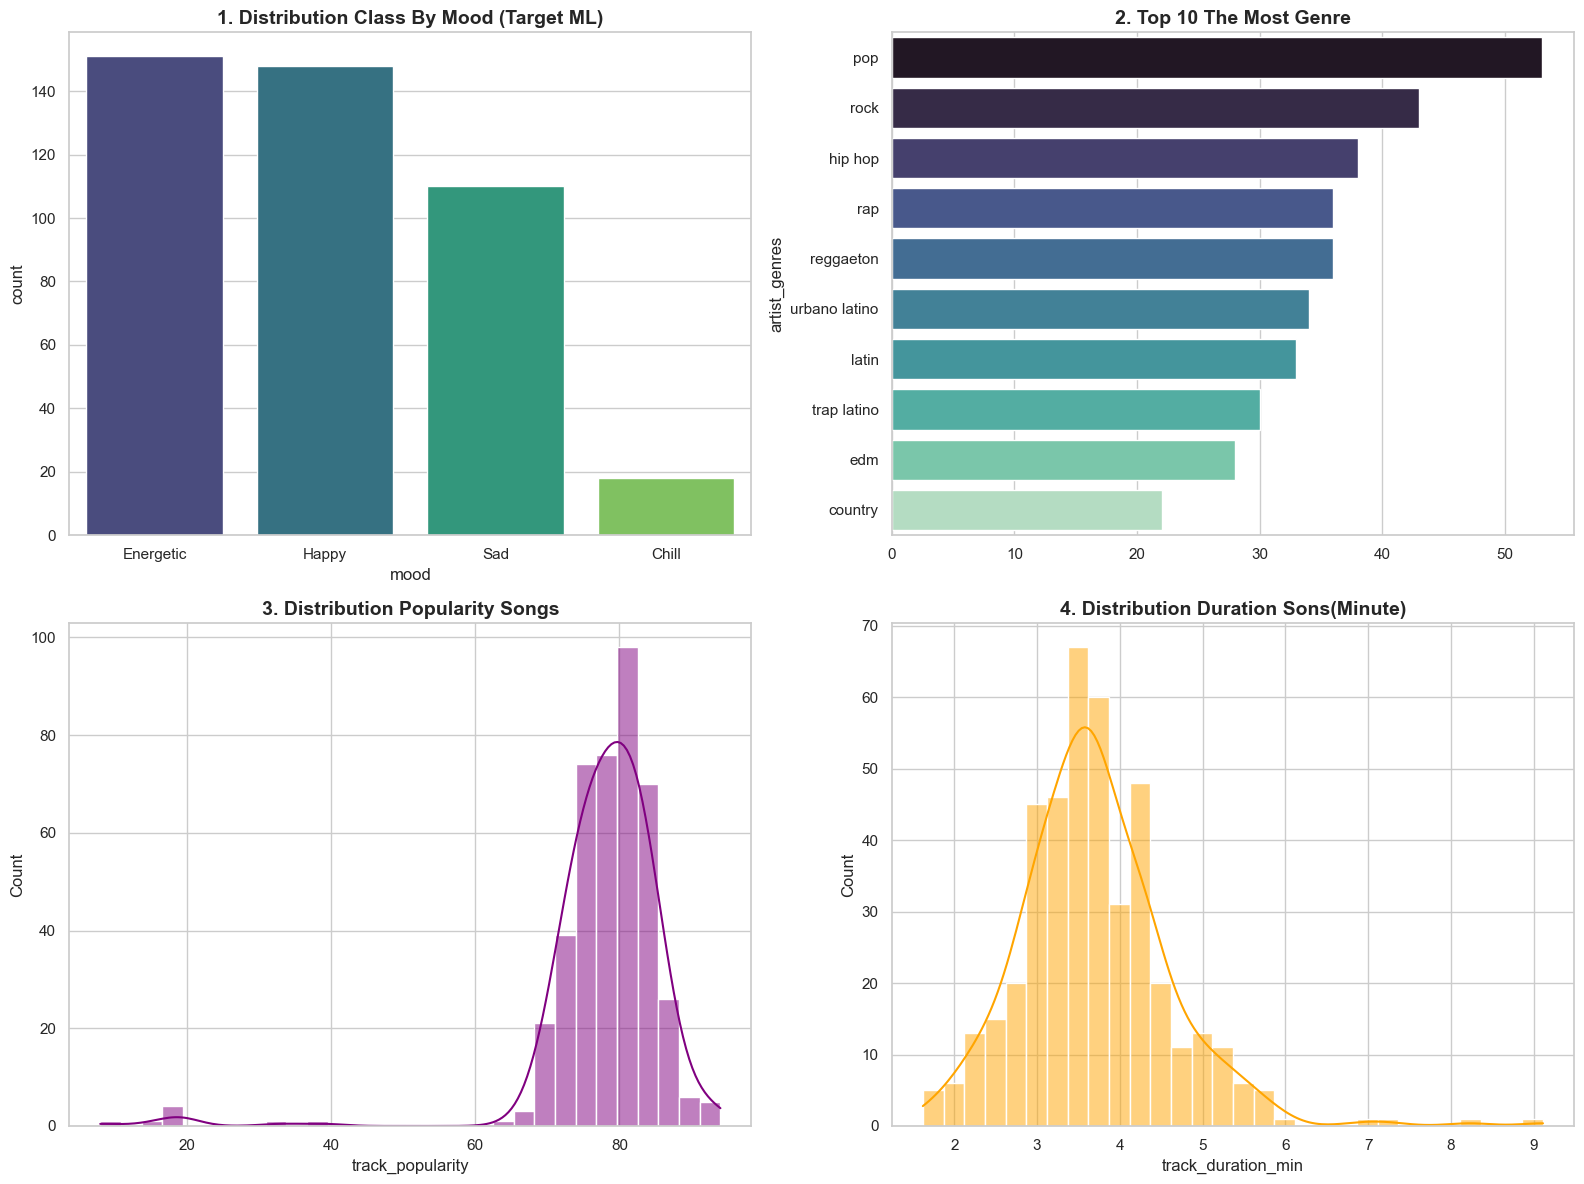

In [23]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Grafic 1: Target Distribution (Mood)
sns.countplot(data=df, x='mood', palette='viridis', order=df['mood'].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title('1. Distribution Class By Mood (Target ML)', fontsize=14, fontweight='bold')

# Grafic 2: Top 10 genre
all_genres = df['artist_genres'].str.split(',').explode().str.strip()
top_genres = all_genres.value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='mako', ax=axes[0, 1])
axes[0, 1].set_title('2. Top 10 The Most Genre', fontsize=14, fontweight='bold')

# Grafik 3: Popularity Distribution
sns.histplot(df['track_popularity'], bins=30, kde=True, color='purple', ax=axes[1, 0])
axes[1, 0].set_title('3. Distribution Popularity Songs', fontsize=14, fontweight='bold')

# Grafik 4: Duration Distribution
sns.histplot(df['track_duration_min'], bins=30, kde=True, color='orange', ax=axes[1, 1])
axes[1, 1].set_title('4. Distribution Duration Sons(Minute)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Audio Features Correlation

--- Audio Features Correlation ---


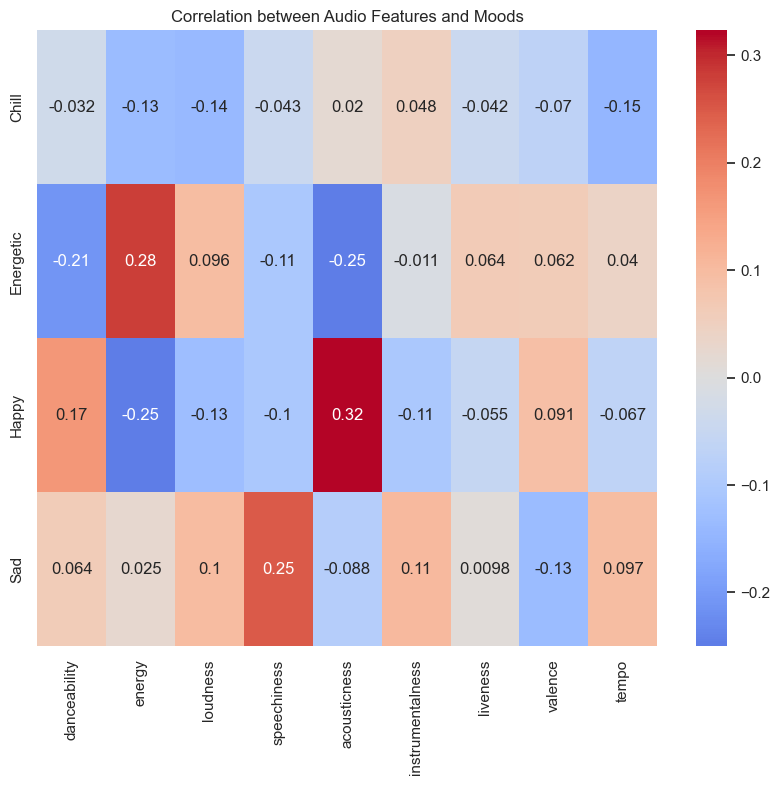

In [24]:
print("--- Audio Features Correlation ---")
plt.figure(figsize=(10, 8))

mood_dummies = pd.get_dummies(df['mood'])
corr_df = pd.concat([df[audio_features], mood_dummies], axis=1)
sns.heatmap(corr_df.corr().loc[mood_dummies.columns, audio_features], annot=True, cmap='coolwarm', center=0)
plt.title("Correlation between Audio Features and Moods")
plt.show()

Machine Learning

--- Building Machine Learning ---

Evaluating Model: SVC
Accuracy: 0.8140

Classification Report:
              precision    recall  f1-score   support

       Chill       0.00      0.00      0.00         3
   Energetic       0.77      0.87      0.82        31
       Happy       0.79      0.87      0.83        30
         Sad       0.94      0.77      0.85        22

    accuracy                           0.81        86
   macro avg       0.63      0.63      0.62        86
weighted avg       0.79      0.81      0.80        86



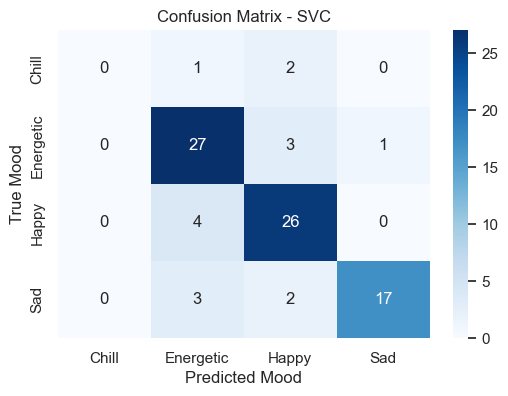


Evaluating Model: Random Forest
Accuracy: 0.9070

Classification Report:
              precision    recall  f1-score   support

       Chill       0.00      0.00      0.00         3
   Energetic       0.89      1.00      0.94        31
       Happy       0.97      0.97      0.97        30
         Sad       0.90      0.82      0.86        22

    accuracy                           0.91        86
   macro avg       0.69      0.70      0.69        86
weighted avg       0.89      0.91      0.90        86



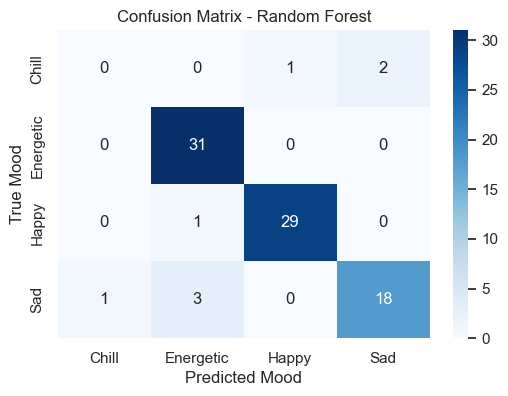


Evaluating Model: Logistic Regression
Accuracy: 0.9186

Classification Report:
              precision    recall  f1-score   support

       Chill       1.00      0.33      0.50         3
   Energetic       0.91      0.97      0.94        31
       Happy       0.94      0.97      0.95        30
         Sad       0.90      0.86      0.88        22

    accuracy                           0.92        86
   macro avg       0.94      0.78      0.82        86
weighted avg       0.92      0.92      0.91        86



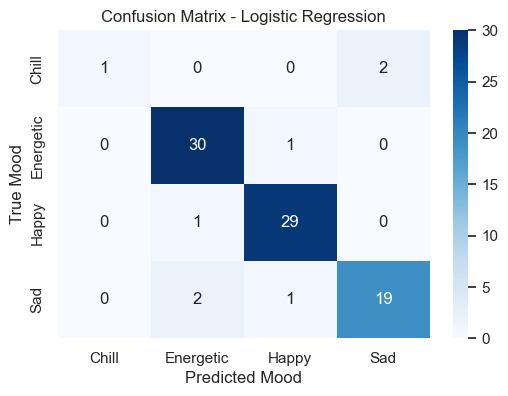


--- Model Comparison Summary ---


,Model,Accuracy
2,Logistic Regression,0.918605
1,Random Forest,0.906977
0,SVC,0.813953


In [25]:
print("--- Building Machine Learning ---")

X = df[audio_features + ['text_feature']]
y = df['mood']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hybrid Preprocessor (Audio Features + Text Features)
preprocessor = ColumnTransformer(
    transformers=[
        ('audio', StandardScaler(), audio_features),
        ('text', TfidfVectorizer(max_features=100), 'text_feature')
    ])

# Dictionary of models to compare
models = {
    "SVC": Pipeline([('preprocessor', preprocessor), ('classifier', SVC(kernel='rbf', random_state=42))]),
    "Random Forest": Pipeline([('preprocessor', preprocessor), ('classifier', RandomForestClassifier(random_state=42))]),
    "Logistic Regression": Pipeline([('preprocessor', preprocessor), ('classifier', LogisticRegression(random_state=42, max_iter=1000))])
}

results = []

for name, pipeline in models.items():
    print(f"\nEvaluating Model: {name}")
    print("="*40)
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc})
    
    print(f"Accuracy: {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    # Confusion Matrix Visualization
    cm = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=pipeline.classes_, yticklabels=pipeline.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.ylabel('True Mood')
    plt.xlabel('Predicted Mood')
    plt.show()

# Model Comparison Table
print("\n--- Model Comparison Summary ---")
df_results = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
display(df_results)

ml_pipeline = models[df_results.iloc[0]['Model']]

Analyzing the correlation between Artist Genres and AI Moods...


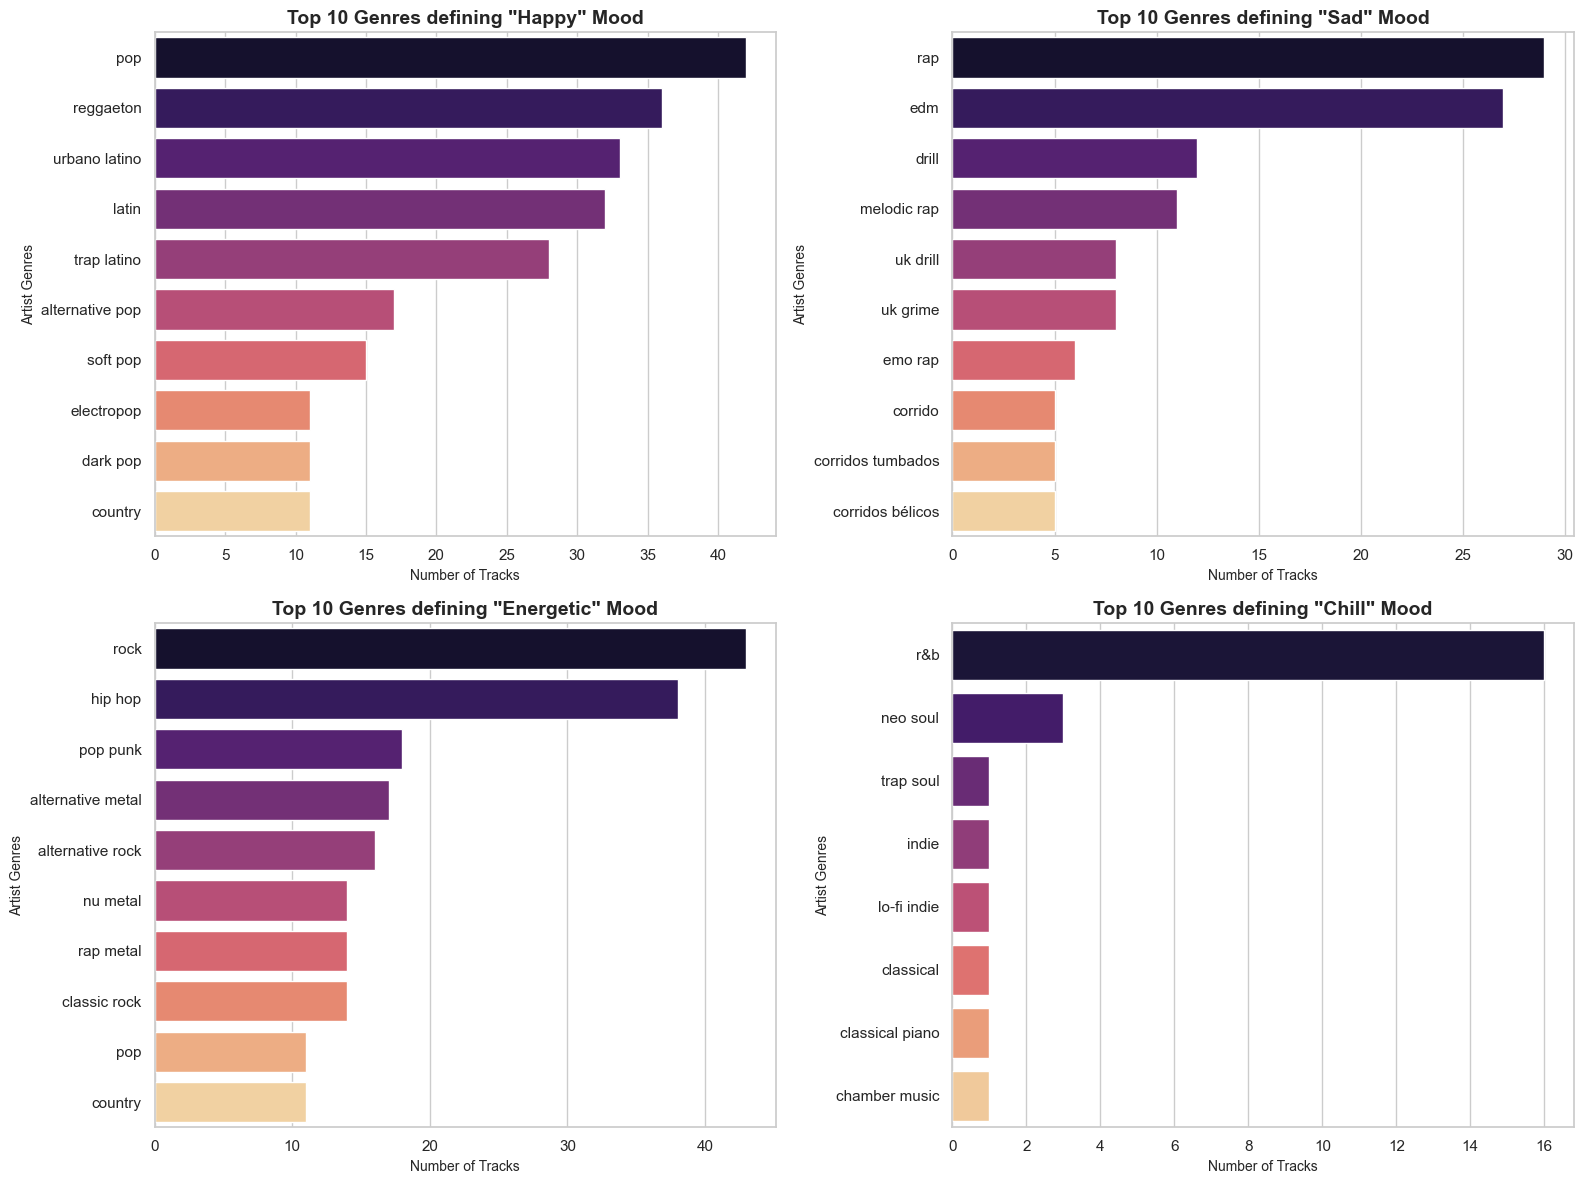

In [26]:
print("Analyzing the correlation between Artist Genres and AI Moods...")

unique_moods = df['mood'].unique()
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, mood in enumerate(unique_moods):
    mood_data = df[df['mood'] == mood]
    
    all_genres = mood_data['artist_genres'].astype(str).str.split(',').explode().str.strip()
    top_10_genres = all_genres.value_counts().head(10)

    sns.barplot(x=top_10_genres.values, y=top_10_genres.index, ax=axes[i], palette='magma')

    axes[i].set_title(f'Top 10 Genres defining "{mood}" Mood', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Number of Tracks', fontsize=10)
    axes[i].set_ylabel('Artist Genres', fontsize=10)

plt.tight_layout()
plt.show()

DAG

In [27]:
from sklearn import set_config

set_config(display='diagram')

display(ml_pipeline)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('audio', ...), ('text', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

UI

Common genre

In [28]:
print("--- 🎵 Music Generator UI 🎵 ---")

common_genres = [
    'Pop', 'Rock', 'Hip Hop', 'R&B', 'Country',
    'Jazz', 'Electronic', 'Classical', 'Blues',
    'Indie', 'Metal', 'Reggae', 'Dance'
]
unique_moods = sorted(df['mood'].unique().tolist())

mood_dropdown = widgets.Dropdown(options=['Any'] + unique_moods, value='Any', description='Mood:')
genre_dropdown = widgets.Dropdown(options=['Any'] + common_genres, value='Any', description='Genre:')
generate_button = widgets.Button(description="Generate Music", button_style='success', icon='music')
output = widgets.Output()

def on_button_clicked(b):
    with output:
        output.clear_output()
        selected_genre = genre_dropdown.value
        selected_mood = mood_dropdown.value

        filtered_df = df.copy()

        if selected_genre != 'Any':
            search_term = selected_genre.lower()
            filtered_df = filtered_df[filtered_df['artist_genres'].str.contains(search_term, case=False, na=False)]

        if selected_mood != 'Any':
            filtered_df = filtered_df[filtered_df['mood'] == selected_mood]

        if filtered_df.empty:
            print(f"❌ No songs found for Genre: {selected_genre} and Mood: {selected_mood}. Try another combination!")
        else:
            print(f"✅ AI recommends songs for Genre: '{selected_genre}' & Mood: '{selected_mood}'!\n")

            sample_size = min(3, len(filtered_df))
            recommendations = filtered_df.sample(sample_size)

            for idx, row in recommendations.iterrows():
                track_id = row['track_id']
                spotify_player = f"""
                <div style="margin-bottom: 5px;">
                    <iframe src="https://open.spotify.com/embed/track/{track_id}"
                            width="300" height="80" frameborder="0"
                            allowtransparency="true" allow="encrypted-media">
                    </iframe>
                </div>
                """
                display(HTML(spotify_player))

generate_button.on_click(on_button_clicked)
display(mood_dropdown, genre_dropdown, generate_button, output)

--- 🎵 Music Generator UI 🎵 ---


Dropdown(description='Mood:', options=('Any', 'Chill', 'Energetic', 'Happy', 'Sad'), value='Any')

Dropdown(description='Genre:', options=('Any', 'Pop', 'Rock', 'Hip Hop', 'R&B', 'Country', 'Jazz', 'Electronic…

Button(button_style='success', description='Generate Music', icon='music', style=ButtonStyle())

Output()